# Mammalian cell-cycle limit cycle → synthetic scRNA-seq with a ground-truth vector field

**Purpose.** Produce an `AnnData` object whose `X` looks like single-cell mRNA measurements
drawn from a *stationary* (asynchronous) population, and whose `obsm['Field']` holds the
**exact** deterministic `d[mRNA]/dt` at every cell. That gives an unambiguous target against
which a vector-field-recovery method (optimal transport + TDA) can be scored.

**Dynamical core.** The cyclin/Cdk network model of Gérard & Goldbeter:

1. C. Gérard & A. Goldbeter (2009), *Temporal self-organization of the cyclin/Cdk network
   driving the mammalian cell cycle*, **PNAS** 106(51):21643–21648, doi:10.1073/pnas.0903827106
   — the detailed 39-variable / 164-parameter model.
2. C. Gérard & A. Goldbeter (2011), *A skeleton model for the network of cyclin-dependent
   kinases driving the mammalian cell cycle*, **Interface Focus** 1(1):24–35,
   doi:10.1098/rsfs.2010.0008 — the 5-variable backbone. **This is the model we implement.**

---

## How these papers generate a limit cycle

**The structure.** Both papers organise the network around four cyclin/Cdk modules that fire in
sequence: cyclin D/Cdk4–6 in G1, cyclin E/Cdk2 at G1/S, cyclin A/Cdk2 through S and S/G2, and
cyclin B/Cdk1 at G2/M. Two antagonistic regulators gate progression — the transcription factor
E2F promotes it, the tumour suppressor pRB blocks it — and the Cdk network phosphorylates both,
closing the loop. The 2011 skeleton model drops pRB, drops Cdc25/Wee1 phosphorylation (and hence
the positive-feedback-driven bistability), drops p21/p27, drops Skp2/Cdh1, and keeps five
dynamical variables: E2F, Me, Ma, Mb, Cdc20. Cyclin D/Cdk4–6 is uncoupled from the rest and
relaxes to a growth-factor-set steady state, so it appears as an algebraic equation.

**The oscillation mechanism is delayed negative feedback, not bistability.** The 2011 paper
identifies **three** negative-feedback circuits, each of which can oscillate on its own:

| circuit | loop | what it does |
|---|---|---|
| A, B | E2F → cyclin E/Cdk2 and cyclin A/Cdk2 → E2F inactivation | Cdk2-only oscillations ⇒ endoreplication (rounds of S phase without mitosis) |
| C | cyclin A/Cdk2 → cyclin B/Cdk1 → Cdc20 → degradation of cyclins A and B | the mitotic oscillator, drives the full G1→S→G2→M cycle |

The general principle is Goldbeter's: a negative loop with enough **phase lag** and enough
**nonlinear gain** destabilises its own steady state. Here the lag comes from the length of the
loop (Ma → Mb → Cdc20 → degradation of Ma and Mb is three steps), and the gain from
Goldbeter–Koshland zero-order ultrasensitivity — every covalent-modification cycle
(E2F ⇄ E2F-P, Cdc20 ⇄ Cdc20-P) and every degradation term runs with a Michaelis constant far
below the substrate level (`Kdb = 0.005 µM` against ~3 µM of cyclin B), so those steps behave
like sharp switches.

**The bifurcation.** Growth factor `GF` is the control parameter. Below threshold the system sits
on a stable steady state with all cyclins low — quiescence, G0. Raising `GF` past a critical value
destabilises that fixed point through a **Hopf bifurcation** and a stable limit cycle appears:
temporal self-organisation, i.e. proliferation. The 2011 paper is explicit that the bifurcation
is **supercritical in the skeleton model** (amplitude grows continuously from zero, and the
trajectory spirals outward over several cycles before settling) whereas it is **subcritical in the
detailed 2009 model** (the limit cycle is reached immediately, at full amplitude). That difference
is attributable to the positive feedback loops — Cdk1↔Cdc25 mutual activation and Cdk1⊣Wee1 mutual
inhibition — present only in the detailed model. Positive feedback is therefore responsible for
the *sharpness* of the transitions, not for the existence of the oscillation. The same paper also
reports birhythmicity near `GF ≈ 0.1 µM`, plus quasi-periodicity and chaos elsewhere in parameter
space, all arising from the interference between circuits A, B and C.

**Practical consequence for us:** we must keep `GF` well clear of the interesting region.
We use `GF = 1 µM` (the published value, and ~10× above threshold), where there is a single,
large-amplitude, globally attracting limit cycle.

## Extending the skeleton model with transcription

The published model has no mRNA in it — cyclin synthesis is written as `v_s · TF` directly. Since
we need RNA-like observables, we insert an explicit transcriptional layer, as specified:

$$\frac{d[\mathrm{mRNA}_X]}{dt}=\alpha_X\,\mathrm{TF}_X-\beta_X[\mathrm{mRNA}_X],\qquad
\frac{d[\mathrm{Protein}_X]}{dt}=k_X[\mathrm{mRNA}_X]-(\text{degradation, unchanged})$$

with the transcriptional wiring taken straight from the paper's Figure 1:

| transcript | activator | phase |
|---|---|---|
| `CCND1` | `GF/(Kgf+GF)` | constitutive under constant GF |
| `CCNE1` | E2F | G1/S |
| `CCNA2` | E2F | S |
| `CCNB1` | cyclin A/Cdk2 | G2/M |

**Why this does not destroy the limit cycle.** Two arguments, and we check both numerically below.

*Quasi-steady-state matching.* Let $\varepsilon = 1/\beta$ be the mRNA relaxation time. As
$\varepsilon\to 0$ the transcript is slaved to its activator, $[\mathrm{mRNA}_X]\to(\alpha_X/\beta_X)\,\mathrm{TF}_X$,
and the translation term becomes $k_X(\alpha_X/\beta_X)\mathrm{TF}_X$. We therefore **choose the new
parameters to satisfy**

$$k_X\,\frac{\alpha_X}{\beta_X}=v_{s,X}$$

for each of the four published synthesis constants ($v_{sd}=0.175$, $v_{se}=0.21$, $v_{sa}=0.175$,
$v_{sb}=0.21$). In the singular limit the extended model reduces **exactly** to Gérard–Goldbeter (2011);
every other parameter is left at its published Table 2 value. The extended system is a regular
perturbation of a model with a hyperbolic (exponentially stable) limit cycle, and hyperbolic limit
cycles persist under small smooth perturbations, so the attractor survives for finite $\varepsilon$.

*Direction of the perturbation.* The correction is not neutral, and it is worth being explicit that
it helps rather than hurts: adding a first-order lag inside a negative-feedback loop *increases*
the phase lag, which is destabilising for the fixed point and therefore **enlarges** the oscillatory
region. Concretely, the period lengthens from **23.6 h** (pure skeleton) to **≈25.0 h** here.

We set $\beta \approx 2.5$–$3\ \mathrm{h}^{-1}$ (mRNA half-life 14–17 min, i.e. ~1/60 of the period) so
that the reduction is a good approximation, and $k_s = 0.5\ \mathrm{h}^{-1}$, which fixes
$\alpha_X = v_{s,X}\beta_X/k_X$ and puts transcript levels on a µM-like scale comparable to the proteins.

`CCNA2` is deliberately given $\beta_a=2.5$ rather than $3.0$. With identical decay constants,
`CCNE1` and `CCNA2` — both pure E2F targets — would be **exactly proportional**, an artificial
rank deficiency that would flatter any manifold-learning method.

**Four passive reporter transcripts** (`MCM6`, `PCNA` driven by E2F; `PLK1`, `AURKA` driven by
cyclin B/Cdk1) are added as read-outs. They receive input but send none: the coupled system is a
skew product, so the dynamics on the attractor are untouched while the ambient dimension of the
observed data rises to 8. Their decay constants are spread over 0.35–1.2 h⁻¹ so each carries a
different phase lag and amplitude — no two observed genes are collinear.

In [1]:
# Requirements:  pip install tellurium anndata numpy scipy matplotlib pandas
import numpy as np
import matplotlib.pyplot as plt
import anndata
import tellurium as te
import pandas as pd

import cellcycle_model as ccm     # auxiliary functions only (see cellcycle_model.py)

# ----------------------------- configuration ------------------------------
GF            = 1.0      # growth factor [uM] -- an order of magnitude above the Hopf threshold
N_CELLS       = 3000     # exactly N = 3000 sampled states
N_PERIODS     = 8        # sample over an integer number of periods -> unbiased phase distribution
T_BURN_IN     = 200.0    # [h] transient discarded before any sampling
NOISE_FRAC    = 0.05     # measurement noise, relative to the RMS spread of the data
SEED          = 0

rng_info = dict(GF=GF, N_CELLS=N_CELLS, N_PERIODS=N_PERIODS,
                T_BURN_IN=T_BURN_IN, NOISE_FRAC=NOISE_FRAC, SEED=SEED)
print(rng_info)
print("tellurium", te.__version__)

{'GF': 1.0, 'N_CELLS': 3000, 'N_PERIODS': 8, 'T_BURN_IN': 200.0, 'NOISE_FRAC': 0.05, 'SEED': 0}
tellurium 2.2.13


## 1. The ODE system (Antimony)

Below is the complete model. Units: concentrations in µM, time in **hours**.

Two implementation notes:

* Every state variable is declared as a `species` inside a compartment. This is bookkeeping, not
  biology: if the variables are left as bare rate-rule symbols, libRoadRunner classifies them as
  global parameters, `getFloatingSpeciesIds()` returns an empty list, and there is no reliable way
  to line up `getRatesOfChange()` with variable names. Declaring them as species makes that mapping
  well defined — which is exactly what step 4 of this notebook depends on.
* Antimony will not accept a rate rule split across lines, so each ODE is one line.

In [2]:
ANTIMONY_MODEL = r"""
model mammalian_cell_cycle_mRNA()

  # ---- state variables, declared as species -------------------------------
  # Bookkeeping, not biology: declaring these as species (rather than leaving
  # them as bare rate-rule symbols) is what makes getFloatingSpeciesIds() and
  # getRatesOfChange() line up, which section 4 depends on.
  compartment cell = 1;
  species Md in cell, E2F in cell, Me in cell, Ma in cell, Mb in cell, Cdc20 in cell;
  species mRNA_CCND1 in cell, mRNA_CCNE1 in cell, mRNA_CCNA2 in cell, mRNA_CCNB1 in cell;
  species mRNA_MCM6 in cell, mRNA_PCNA in cell, mRNA_PLK1 in cell, mRNA_AURKA in cell;

  # =========================================================================
  # PROTEIN / ACTIVITY LAYER
  # Gerard & Goldbeter (2011) eqs. (2.1)-(2.6), with each cyclin synthesis term
  # v_s * TF replaced by translation from its transcript, k_s * mRNA.
  # =========================================================================

  # cyclin D/Cdk4-6 -- translated from CCND1 mRNA, Michaelian degradation.
  # Receives no feedback from the rest of the network: under constant GF it
  # settles at Md = Kdd*S/(Vdd-S) with S = vsd*GF/(Kgf+GF), i.e. 0.1852 uM,
  # reproducing eq. (2.7) of the paper.
  Md'  = ksd*mRNA_CCND1 - Vdd*Md/(Kdd + Md);

  # E2F -- Goldbeter-Koshland covalent-modification cycle with a fixed total pool.
  #   ACTIVATED by cyclin D/Cdk4-6 and cyclin E/Cdk2  -> POSITIVE feedback via Me
  #   INACTIVATED by cyclin A/Cdk2                    -> closes oscillators A and B
  # K1e2f = K2e2f = 0.01 uM << E2Ftot = 3 uM, so both arms run zero-order:
  # this is the ultrasensitivity that supplies the gain needed for the Hopf.
  E2F' = V1e2f*(Md + Me)*(E2Ftot - E2F)/(K1e2f + E2Ftot - E2F) - V2e2f*Ma*E2F/(K2e2f + E2F);

  # cyclin E/Cdk2 -- degradation is proportional to cyclin A/Cdk2, the skeleton
  # model's stand-in for Skp2-mediated turnover. Guarantees cyclin E is off by S phase.
  Me'  = kse*mRNA_CCNE1 - Vde*Ma*Me/(Kde + Me);

  # cyclin A/Cdk2 -- degraded by active Cdc20 (APC/C)
  Ma'  = ksa*mRNA_CCNA2 - Vda*Cdc20*Ma/(Kda + Ma);

  # cyclin B/Cdk1 -- degraded by active Cdc20 (APC/C).
  # Kdb = 0.005 uM against ~3 uM of substrate: near-zero-order, hence the
  # near-vertical drop at mitotic exit (and the stiffness that forces tight tolerances).
  Mb'  = ksb*mRNA_CCNB1 - Vdb*Cdc20*Mb/(Kdb + Mb);

  # Cdc20 -- activated by phosphorylation by cyclin B/Cdk1, then degrades cyclins
  # A and B. THIS IS THE CORE NEGATIVE FEEDBACK LOOP (oscillator C of the paper).
  Cdc20' = V1cdc20*Mb*(Cdc20tot - Cdc20)/(K1cdc20 + Cdc20tot - Cdc20) - V2cdc20*Cdc20/(K2cdc20 + Cdc20);

  # =========================================================================
  # TRANSCRIPTIONAL LAYER      d[mRNA]/dt = alpha * TF - beta * [mRNA]
  # Wiring taken directly from Figure 1 of Gerard & Goldbeter (2011).
  # =========================================================================
  mRNA_CCND1' = a_d*(GF/(Kgf + GF)) - b_d*mRNA_CCND1;   # growth-factor driven, NOT cyclic
  mRNA_CCNE1' = a_e*E2F             - b_e*mRNA_CCNE1;   # E2F target, peaks at G1/S
  mRNA_CCNA2' = a_a*E2F             - b_a*mRNA_CCNA2;   # E2F target, peaks in S
  mRNA_CCNB1' = a_b*Ma              - b_b*mRNA_CCNB1;   # driven by cyclin A/Cdk2, peaks at G2/M

  # ---- passive reporter transcripts: input only, no output ----------------
  # One-way coupling => skew-product structure => the attractor is unchanged,
  # but the ambient dimension of the observed data rises from 4 to 8.
  mRNA_MCM6'  = a_mcm*E2F  - b_mcm*mRNA_MCM6;    # replication licensing, E2F target
  mRNA_PCNA'  = a_pcna*E2F - b_pcna*mRNA_PCNA;   # E2F target, slow turnover -> large phase lag
  mRNA_PLK1'  = a_plk*Mb   - b_plk*mRNA_PLK1;    # mitotic, driven by cyclin B/Cdk1
  mRNA_AURKA' = a_aur*Mb   - b_aur*mRNA_AURKA;   # mitotic, slow turnover -> large phase lag

  # =========================== INITIAL CONDITIONS ==========================
  # Deliberately far from the attractor, so that the burn-in has real work to do.
  Md = 0.01; E2F = 0.01; Me = 0.01; Ma = 0.01; Mb = 0.01; Cdc20 = 0.01;
  mRNA_CCND1 = 0.01; mRNA_CCNE1 = 0.01; mRNA_CCNA2 = 0.01; mRNA_CCNB1 = 0.01;
  mRNA_MCM6 = 0.01; mRNA_PCNA = 0.01; mRNA_PLK1 = 0.01; mRNA_AURKA = 0.01;

  # ============ PARAMETERS -- Gerard & Goldbeter (2011), Table 2 ===========
  # Concentrations in uM, time in hours. Unchanged from the publication.
  GF = 1;            # growth factor -- ~10x above the oscillation threshold
  Cdc20tot = 5;      # total Cdc20
  E2Ftot = 3;        # total E2F

  Kda = 0.1;  Kdb = 0.005;  Kdd = 0.1;  Kde = 0.1;  Kgf = 0.1;    # [uM]
  K1cdc20 = 1;  K2cdc20 = 1;  K1e2f = 0.01;  K2e2f = 0.01;        # [uM]
  Vda = 0.245;  Vdb = 0.28;  Vde = 0.35;                          # [1/h]
  Vdd = 0.245;                                                    # [uM/h]
  V1cdc20 = 0.21;   V2cdc20 = 0.35;                               # [1/h], [uM/h]
  V1e2f = 0.805;    V2e2f = 0.7;                                  # [1/h]

  # ============ ADDED transcription / translation parameters ==============
  # Constrained by the quasi-steady-state matching condition
  #        k_s * alpha / beta  ==  v_s        (published v_s values)
  #   v_sd = 0.175, v_se = 0.21, v_sa = 0.175, v_sb = 0.21   [Table 2]
  # so that as beta -> infinity the system reduces EXACTLY to the published
  # 5-variable skeleton model. Nothing else was retuned.
  ksd = 0.5;   kse = 0.5;   ksa = 0.5;    ksb = 0.5;      # translation [1/h]
  b_d = 3.0;   b_e = 3.0;   b_a = 2.5;    b_b = 3.0;      # mRNA decay  [1/h]  (t1/2 = 14-17 min)
  a_d = 1.05;  a_e = 1.26;  a_a = 0.875;  a_b = 1.26;     # transcription [1/h] = v_s*beta/k_s
  # b_a is 2.5 rather than 3.0 on purpose: with identical decay constants,
  # CCNE1 and CCNA2 (both pure E2F targets) would be EXACTLY proportional --
  # an artificial rank deficiency that would flatter any manifold method.

  # Reporters: alpha == beta keeps amplitude on the scale of the driver, while
  # the spread in beta gives each a distinct phase lag (no two genes collinear).
  a_mcm  = 1.0;   b_mcm  = 1.0;    # t1/2 = 42 min
  a_pcna = 0.4;   b_pcna = 0.4;    # t1/2 = 1.7 h  -> large lag, damped amplitude
  a_plk  = 1.2;   b_plk  = 1.2;    # t1/2 = 35 min
  a_aur  = 0.35;  b_aur  = 0.35;   # t1/2 = 2.0 h  -> large lag
end
"""
print(ANTIMONY_MODEL[:400], "...")


model mammalian_cell_cycle_mRNA()

  # ---- state variables, declared as species -------------------------------
  # Bookkeeping, not biology: declaring these as species (rather than leaving
  # them as bare rate-rule symbols) is what makes getFloatingSpeciesIds() and
  # getRatesOfChange() line up, which section 4 depends on.
  compartment cell = 1;
  species Md in cell, E2F in cell, Me in cell, ...


## 2. Compile, burn in, and measure the period

In [3]:
rr = ccm.build_model(ANTIMONY_MODEL, GF=GF)

STATE_IDS = ccm.state_ids(rr)          # order of the ODE state vector == order of getRatesOfChange()
MRNA_IDX  = ccm.mrna_indices(rr)       # columns of the state vector that are transcripts
print(f"{len(STATE_IDS)} state variables:")
print("  proteins/activities :", [s for s in STATE_IDS if not s.startswith('mRNA_')])
print("  transcripts         :", [s for s in STATE_IDS if s.startswith('mRNA_')])

14 state variables:
  proteins/activities : ['Md', 'E2F', 'Me', 'Ma', 'Mb', 'Cdc20']
  transcripts         : ['mRNA_CCND1', 'mRNA_CCNE1', 'mRNA_CCNA2', 'mRNA_CCNB1', 'mRNA_MCM6', 'mRNA_PCNA', 'mRNA_PLK1', 'mRNA_AURKA']


In [4]:
# --------------------------- BURN-IN --------------------------------------
# Initial condition is 0.01 uM for every variable -- far off the attractor on
# purpose, so that convergence to the cycle is something we observe rather than
# something we assume.  The transient is integrated and thrown away.
transient = ccm.burn_in(rr, t_end=T_BURN_IN, n_points=20_001)

t_tr = transient[:, 0]
mb   = transient[:, 1 + STATE_IDS.index("Mb")]
print("peak-to-trough amplitude of cyclin B/Cdk1 in successive 40 h windows:")
for lo in (20, 60, 100, 140, 160):
    w = mb[(t_tr > lo) & (t_tr < lo + 40)]
    print(f"   t in [{lo:3d}, {lo + 40:3d}] h : {np.ptp(w):.5f} uM")
print("\nThe amplitude GROWS and then flattens. That is not a bug: the 2011 paper")
print("states the Hopf bifurcation is SUPERCRITICAL in the skeleton model, so the")
print("trajectory spirals outward over several cycles before settling. (The detailed")
print("2009 model is subcritical and lands on the cycle immediately.) This is exactly")
print("why a burn-in is mandatory rather than cosmetic.")
print("\nRoadRunner is now sitting on the attractor; all sampling continues from here.")

peak-to-trough amplitude of cyclin B/Cdk1 in successive 40 h windows:
   t in [ 20,  60] h : 2.66755 uM
   t in [ 60, 100] h : 3.21932 uM
   t in [100, 140] h : 3.24035 uM
   t in [140, 180] h : 3.24091 uM
   t in [160, 200] h : 3.24100 uM

The amplitude GROWS and then flattens. That is not a bug: the 2011 paper
states the Hopf bifurcation is SUPERCRITICAL in the skeleton model, so the
trajectory spirals outward over several cycles before settling. (The detailed
2009 model is subcritical and lands on the cycle immediately.) This is exactly
why a burn-in is mandatory rather than cosmetic.

RoadRunner is now sitting on the attractor; all sampling continues from here.


In [5]:
# --------------------------- PERIOD ---------------------------------------
PERIOD = ccm.estimate_period(rr, marker="Mb")
print(f"limit-cycle period  T = {PERIOD:.4f} h")
print("(the pure 5-variable skeleton model gives 23.57 h; the transcriptional lag adds ~1.4 h,")
print(" which is the expected sign: more phase lag in a negative-feedback loop = slower oscillator)")

# ---- convergence certificate ---------------------------------------------
# Integrate one further period from where we are and measure the drift,
# relative to the diameter of the orbit.  On the limit cycle this is zero;
# what we measure bounds (residual transient + error in T) in one number.
loop     = np.asarray(rr.simulate(0.0, PERIOD, 4001))[:, 1:]
diameter = 2 * np.linalg.norm(loop - loop.mean(0), axis=1).max()
closure  = np.linalg.norm(loop[-1] - loop[0]) / diameter
print(f"\nclosure error  ||x(T) - x(0)|| / diameter = {closure:.2e}")
assert closure < 1e-3, "not on the attractor yet - lengthen T_BURN_IN"
print("-> the sampled states lie on the attractor to ~8 significant figures.")

limit-cycle period  T = 24.9794 h
(the pure 5-variable skeleton model gives 23.57 h; the transcriptional lag adds ~1.4 h,
 which is the expected sign: more phase lag in a negative-feedback loop = slower oscillator)

closure error  ||x(T) - x(0)|| / diameter = 2.23e-08
-> the sampled states lie on the attractor to ~8 significant figures.


## 3. Sampling the stationary distribution

**The measure matters more than the mechanics here.** A real asynchronous, non-growing culture
occupies each point of the cycle in proportion to the time a cell spends there. For a deterministic
flow $\dot x = f(x)$ on a closed orbit parameterised by arc length $s$, the invariant density is

$$\rho(s)\;\propto\;\frac{1}{\lVert f(x(s))\rVert},$$

which is precisely the push-forward of the uniform measure on $[0,T)$ under $t\mapsto x(t)$.
**Sampling uniformly in time therefore samples the stationary distribution exactly** — no
importance reweighting, no rejection step.

This is the crux of the test: cells pile up where the flow is slow (G1) and thin out across the
fast mitotic spike, so **density and speed are inversely coupled**. A method that mistakes
"few points here" for "nothing happens here" will fail; the correct answer is the opposite.

Two smaller choices:
* Sampling spans **`N_PERIODS` whole periods**, so the empirical phase distribution is exactly
  uniform rather than biased by a partial cycle.
* Sample times are drawn **without replacement from a dense uniform grid** (40× oversampled,
  spacing ≈ 5 × 10⁻³ h). This is i.i.d.-uniform up to a grid resolution far below every timescale
  in the model, but keeps every sampled state exactly on the integrated trajectory — no
  interpolation error creeping into the ground truth.

In [6]:
t_sample, X_full, _ = ccm.sample_limit_cycle(
    rr, n_cells=N_CELLS, period=PERIOD, n_periods=N_PERIODS, seed=SEED
)
print("sampled states :", X_full.shape, "(cells x full state vector)")
print(f"time window    : [{t_sample.min():.2f}, {t_sample.max():.2f}] h "
      f"= {N_PERIODS} periods, all post-burn-in")

sampled states : (3000, 14) (cells x full state vector)
time window    : [0.04, 199.76] h = 8 periods, all post-burn-in


## 4. The ground-truth vector field

For each sampled state we push it back into the compiled model and read the exact right-hand side
of the ODEs, `rr.getRatesOfChange()`. No finite differences, no interpolation, no numerical
differentiation of the sampled trajectory — an analytic evaluation of $f(x)$ at the sampled $x$.
The columns corresponding to transcripts become `adata.obsm['Field']`.

The cell below **verifies** the two things this depends on: that `getRatesOfChange()` is ordered
like `getFloatingSpeciesIds()`, and that the values really are $f(x)$. It does so by comparing
against high-resolution central differences of an independently integrated trajectory.

In [7]:
# ---- verification: exact RHS vs. central finite differences ---------------
rr_chk = ccm.build_model(ANTIMONY_MODEL, GF=GF, atol=1e-12, rtol=1e-12)
ccm.burn_in(rr_chk, 200.0, 20_001)
h_chk  = 1e-3
chk    = np.asarray(rr_chk.simulate(0.0, 50.0, int(50.0 / h_chk) + 1))
fd     = (chk[2:, 1:] - chk[:-2, 1:]) / (2 * h_chk)          # O(h^2) central difference
exact  = ccm.exact_rates(rr_chk, chk[1:-1, 1:])              # analytic f(x) at the same states

# Normalise by the GLOBAL largest rate, not the per-variable one: Md and
# mRNA_CCND1 sit at steady state on the attractor, so their own scale is ~0 and
# a per-variable ratio would be 0/0.
scale = np.abs(exact).max()
abs_err = np.abs(exact - fd).max(axis=0)
print(f"global rate scale = {scale:.4f} uM/h")
print(f"{'variable':<14s}{'max|f|':>12s}{'max abs err':>14s}{'err/scale':>12s}")
for name, a, e in zip(STATE_IDS, np.abs(exact).max(axis=0), abs_err):
    print(f"   {name:<12s}{a:12.4e}{e:14.2e}{e/scale:12.2e}")
assert abs_err.max() / scale < 5e-3, "RHS query disagrees with the trajectory - do not trust the Field"
print("\nOK: getRatesOfChange() reproduces the trajectory derivative to within "
      f"{abs_err.max()/scale:.1e} of the global rate scale.")
print("(The residual is central-difference truncation error, not a model error:")
print(" it shrinks like h^2 and is largest exactly at the stiff mitotic spike.)")

global rate scale = 1.7474 uM/h
variable            max|f|   max abs err   err/scale
   Md            7.2164e-16      1.45e-14    8.28e-15
   E2F           1.7474e+00      4.05e-04    2.32e-04
   Me            8.4597e-01      1.20e-06    6.89e-07
   Ma            5.5381e-01      2.23e-07    1.28e-07
   Mb            7.0825e-01      9.13e-05    5.23e-05
   Cdc20         2.9874e-01      3.11e-07    1.78e-07
   mRNA_CCND1    6.6613e-16      6.66e-16    3.81e-16
   mRNA_CCNE1    6.7844e-01      8.68e-06    4.97e-06
   mRNA_CCNA2    5.5277e-01      6.10e-06    3.49e-06
   mRNA_CCNB1    2.3154e-01      4.55e-08    2.60e-08
   mRNA_MCM6     1.2663e+00      7.24e-06    4.15e-06
   mRNA_PCNA     7.8300e-01      2.93e-06    1.68e-06
   mRNA_PLK1     6.7910e-01      2.33e-06    1.33e-06
   mRNA_AURKA    5.1061e-01      7.03e-07    4.02e-07

OK: getRatesOfChange() reproduces the trajectory derivative to within 2.3e-04 of the global rate scale.
(The residual is central-difference truncation error, 

In [8]:
# ---- the ground-truth field at the sampled states ------------------------
F_full = ccm.exact_rates(rr, X_full)      # (N, 14) full-state derivative
M_true = X_full[:, MRNA_IDX]              # (N, 8)  noiseless transcript levels
FIELD  = F_full[:, MRNA_IDX]              # (N, 8)  EXACT d[mRNA]/dt
print("M_true", M_true.shape, " FIELD", FIELD.shape)

pd.DataFrame({
    "gene":       ccm.MRNA_GENES,
    "driver":     [ccm.GENE_DRIVER[g] for g in ccm.MRNA_GENES],
    "min [uM]":   M_true.min(0).round(4),
    "max [uM]":   M_true.max(0).round(4),
    "max |d/dt|": np.abs(FIELD).max(0).round(4),
})

M_true (3000, 8)  FIELD (3000, 8)


,gene,driver,min [uM],max [uM],max |d/dt|
0,CCND1,GF (constitutive),0.3182,0.3182,0.0000
1,CCNE1,E2F,0.0004,1.2576,0.6784
2,CCNA2,E2F,0.0004,1.0477,0.5528
3,CCNB1,cyclin A/Cdk2,0.0029,1.4385,0.2315
4,MCM6,E2F,0.0042,2.9814,1.2662
5,PCNA,E2F,0.0886,2.8701,0.7830
6,PLK1,cyclin B/Cdk1,0.0016,3.1859,0.6791
7,AURKA,cyclin B/Cdk1,0.0914,2.8069,0.5106


### A caveat worth stating plainly

`FIELD` is the **projection** of the 14-dimensional vector field onto the 8 observed transcript
coordinates. It is *not* a closed vector field on transcript space: for example
$\dot m_{CCNE1} = \alpha_e\,\mathrm{E2F} - \beta_e m_{CCNE1}$ depends on E2F, a protein that is
never observed. Off the attractor, transcript state does not determine transcript velocity.

**On the attractor it does**, provided the projection of the limit cycle into transcript space is
an *embedding* — i.e. injective, with no self-intersection. The orbit is one-dimensional and
closed, so if the projection is injective then position along the observed curve determines phase,
which determines the hidden protein state, which determines the velocity. If the projection
self-intersected, the "true" field would be genuinely multi-valued at the crossing and no method
could recover it. So this is a property worth *checking*, not assuming: we quantify it as

$$\text{margin}=\frac{\min\{\lVert m(s)-m(s')\rVert : |s-s'|_{\text{cyclic}}>0.05\,T\}}{\operatorname{diam}}$$

and it must be comfortably above zero.

In [9]:
one_period = np.asarray(rr.simulate(0.0, PERIOD, 2001))[:-1, 1:]
M_cycle    = one_period[:, MRNA_IDX]

margin_all = ccm.embedding_margin(M_cycle)
i_e, i_b   = ccm.MRNA_GENES.index("CCNE1"), ccm.MRNA_GENES.index("CCNB1")
margin_2d  = ccm.embedding_margin(M_cycle[:, [i_e, i_b]])

print(f"embedding margin, full 8-gene transcript space : {margin_all:.4f}")
print(f"embedding margin, (CCNE1, CCNB1) plane only    : {margin_2d:.4f}")
assert margin_all > 0.01, "the observed cycle self-intersects; the ground-truth field is ill-posed"
print("\n-> The observed data is a genuinely embedded closed curve. The ground-truth")
print("   field is single-valued as a function of the observed transcript state.")

embedding margin, full 8-gene transcript space : 0.0476
embedding margin, (CCNE1, CCNB1) plane only    : 0.0485

-> The observed data is a genuinely embedded closed curve. The ground-truth
   field is single-valued as a function of the observed transcript state.


## 5. The observation model

Additive i.i.d. Gaussian noise, **isotropic** across genes by default:
$\sigma = \texttt{NOISE\_FRAC}\times\mathrm{RMS}$ of the centred matrix.

*Why isotropic.* Optimal transport with a squared-Euclidean cost, and persistent homology built on
a Euclidean (Vietoris–Rips / kNN) filtration, both treat the ambient metric as meaningful.
Per-gene noise levels would turn the noise ball into an ellipsoid whose axes are set by the
arbitrary units of each gene, silently coupling the recovered geometry to a modelling artefact.
An isotropic tube around the curve is the clean null. Pass `isotropic=False` for per-gene σ.

*Why we do not clip at zero.* Clipping is biologically tidier but censors the Gaussian, breaking
exactly the "closed curve + isotropic Gaussian tube" assumption the recovery method is being tested
against. Left off by default; `clip_negative=True` is available.

*Why not counts.* A negative-binomial count layer would be more realistic, but Poisson/NB noise is
mean-coupled and heteroscedastic, which confounds a geometric test with a normalisation problem.
The right order of operations is: pass the Gaussian test first, then add counts. `M_true` is kept
in `adata.layers['noiseless']` so a count layer can be generated at any time.

In [10]:
X_noisy, sigma = ccm.add_gaussian_noise(
    M_true, noise_frac=NOISE_FRAC, isotropic=True, clip_negative=False, seed=SEED + 1
)
print(f"sigma (isotropic) = {sigma[0]:.4f} uM")
print("per-gene SNR (std of signal / sigma):")
for g, s in zip(ccm.MRNA_GENES, M_true.std(0) / sigma):
    print(f"   {g:<7s} {s:6.2f}" + ("   <- constant gene: pure-noise negative control" if s < 1e-8 else ""))

sigma (isotropic) = 0.0425 uM
per-gene SNR (std of signal / sigma):
   CCND1     0.00   <- constant gene: pure-noise negative control
   CCNE1    12.62
   CCNA2    10.49
   CCNB1    11.92
   MCM6     28.84
   PCNA     24.68
   PLK1     28.35
   AURKA    23.33


## 6. Assembling the `AnnData`

Layout:

| slot | contents |
|---|---|
| `X` | `(3000, 8)` noisy transcript observations — **mRNA only, no proteins** |
| `layers['noiseless']` | the same matrix before noise |
| `obsm['Field']` | `(3000, 8)` **exact** `d[mRNA]/dt` — the recovery target |
| `obsm['X_protein']` | `(3000, 6)` hidden protein/activity state — for diagnostics, not input |
| `obsm['Field_protein']` | exact `d[protein]/dt` |
| `obs['true_time']` | noiseless simulation time [h] |
| `obs['phase']` | position on the cycle, `(t mod T)/T ∈ [0,1)` |
| `obs['cell_cycle_phase']` | G1 / S / G2 / M, from the model's own landmarks |
| `obs['speed']` | `‖Field‖`, i.e. the local flow speed |
| `var` | driver TF, oscillating flag, amplitude |
| `uns` | period, σ, parameters, and the Antimony source |

`obs['phase']` is arguably the more useful ground truth than `true_time`: a stationary population
has no absolute clock, only a circular coordinate. Both are stored.

In [11]:
# ---- landmark phases (G1/S, S/G2, G2/M, mitotic exit) --------------------
lm = np.asarray(rr.simulate(0.0, PERIOD, 4001))
t_lm = lm[:, 0]
marks = {key: float(t_lm[lm[:, 1 + STATE_IDS.index(var)].argmax()] / PERIOD)
         for key, var in [("G1/S", "Me"), ("S/G2", "Ma"),
                          ("G2/M", "Mb"), ("M/G1", "Cdc20")]}
print("landmark phases:", {k: round(v, 3) for k, v in marks.items()})

phase  = (t_sample % PERIOD) / PERIOD
labels = ccm.assign_cycle_phase(phase, marks)

landmark phases: {'G1/S': 0.126, 'S/G2': 0.32, 'G2/M': 0.469, 'M/G1': 0.642}


In [12]:
protein_idx = np.array([STATE_IDS.index(s) for s in STATE_IDS if not s.startswith("mRNA_")])

adata = anndata.AnnData(X=np.asarray(X_noisy, dtype=np.float32))
adata.obs_names = [f"cell_{i:05d}" for i in range(N_CELLS)]
adata.var_names = ccm.MRNA_GENES

# ------------------------------- obs --------------------------------------
adata.obs["true_time"]        = t_sample                      # noiseless simulation time [h]
adata.obs["phase"]            = phase                         # circular coordinate in [0,1)
adata.obs["cell_cycle_phase"] = pd.Categorical(labels, categories=["G1", "S", "G2", "M"])
adata.obs["speed"]            = np.linalg.norm(FIELD, axis=1)

# ------------------------------- var --------------------------------------
adata.var["driver"]      = [ccm.GENE_DRIVER[g] for g in ccm.MRNA_GENES]
adata.var["amplitude"]   = M_true.max(0) - M_true.min(0)
adata.var["oscillating"] = adata.var["amplitude"].values > 1e-6

# ------------------------------- obsm / layers ----------------------------
adata.layers["noiseless"]   = M_true.astype(np.float32)
adata.obsm["Field"]         = FIELD.astype(np.float64)        # <-- the recovery target
adata.obsm["X_protein"]     = X_full[:, protein_idx]
adata.obsm["Field_protein"] = F_full[:, protein_idx]

# ------------------------------- uns --------------------------------------
adata.uns["model"] = dict(
    source="Gerard & Goldbeter 2011 Interface Focus 1:24-35 (skeleton model), "
           "extended with an explicit transcriptional layer",
    antimony=ANTIMONY_MODEL,
    GF=GF, period_hours=PERIOD, n_periods_sampled=N_PERIODS,
    burn_in_hours=T_BURN_IN, noise_sigma=float(sigma[0]),
    noise_model="additive i.i.d. Gaussian, isotropic across genes, not clipped",
    protein_names=[STATE_IDS[i] for i in protein_idx],
    landmark_phases={k.replace("/", "_"): v for k, v in marks.items()},
    seed=SEED,
)

adata

AnnData object with n_obs × n_vars = 3000 × 8
    obs: 'true_time', 'phase', 'cell_cycle_phase', 'speed'
    var: 'driver', 'amplitude', 'oscillating'
    uns: 'model'
    obsm: 'Field', 'X_protein', 'Field_protein'
    layers: None (.X), 'noiseless'

In [13]:
from scipy.spatial import cKDTree
from scipy.stats import spearmanr

print(adata.obs.groupby("cell_cycle_phase", observed=True)
      .agg(n_cells=("phase", "size"),
           mean_speed=("speed", "mean"),
           arc_hours=("phase", lambda p: len(p) / N_CELLS * PERIOD)).round(3))

# The headline property of this dataset: local point density is (strongly)
# ANTI-correlated with the speed of the true flow.  Measured on the noiseless
# coordinates so it reflects geometry, not the noise.
Mn = adata.layers["noiseless"]
dist, _ = cKDTree(Mn).query(Mn, k=21)
local_density = 1.0 / dist[:, 1:].mean(axis=1)          # inverse mean 20-NN distance
rho, pval = spearmanr(local_density, adata.obs["speed"].values)

print(f"\nspeed |f| spans {adata.obs['speed'].min():.3f} - {adata.obs['speed'].max():.3f} uM/h "
      f"({adata.obs['speed'].max() / adata.obs['speed'].min():.1f}x)")
print(f"Spearman(local density, speed) = {rho:.3f}   (p = {pval:.1e})")
print("\nThis is the whole point of the benchmark. Cells accumulate where the flow is")
print("slow; a method that reads 'few points here' as 'little happens here' gets the")
print("answer exactly backwards. Density and velocity magnitude must be disentangled,")
print("and rho ~ -0.9 says the confound is strong enough to matter.")

                  n_cells  mean_speed  arc_hours
cell_cycle_phase                                
G1                   1447       0.565     12.048
S                     544       0.637      4.530
G2                    455       0.901      3.789
M                     554       0.407      4.613

speed |f| spans 0.218 - 1.828 uM/h (8.4x)
Spearman(local density, speed) = -0.915   (p = 0.0e+00)

This is the whole point of the benchmark. Cells accumulate where the flow is
slow; a method that reads 'few points here' as 'little happens here' gets the
answer exactly backwards. Density and velocity magnitude must be disentangled,
and rho ~ -0.9 says the confound is strong enough to matter.


## 7. Validation plots

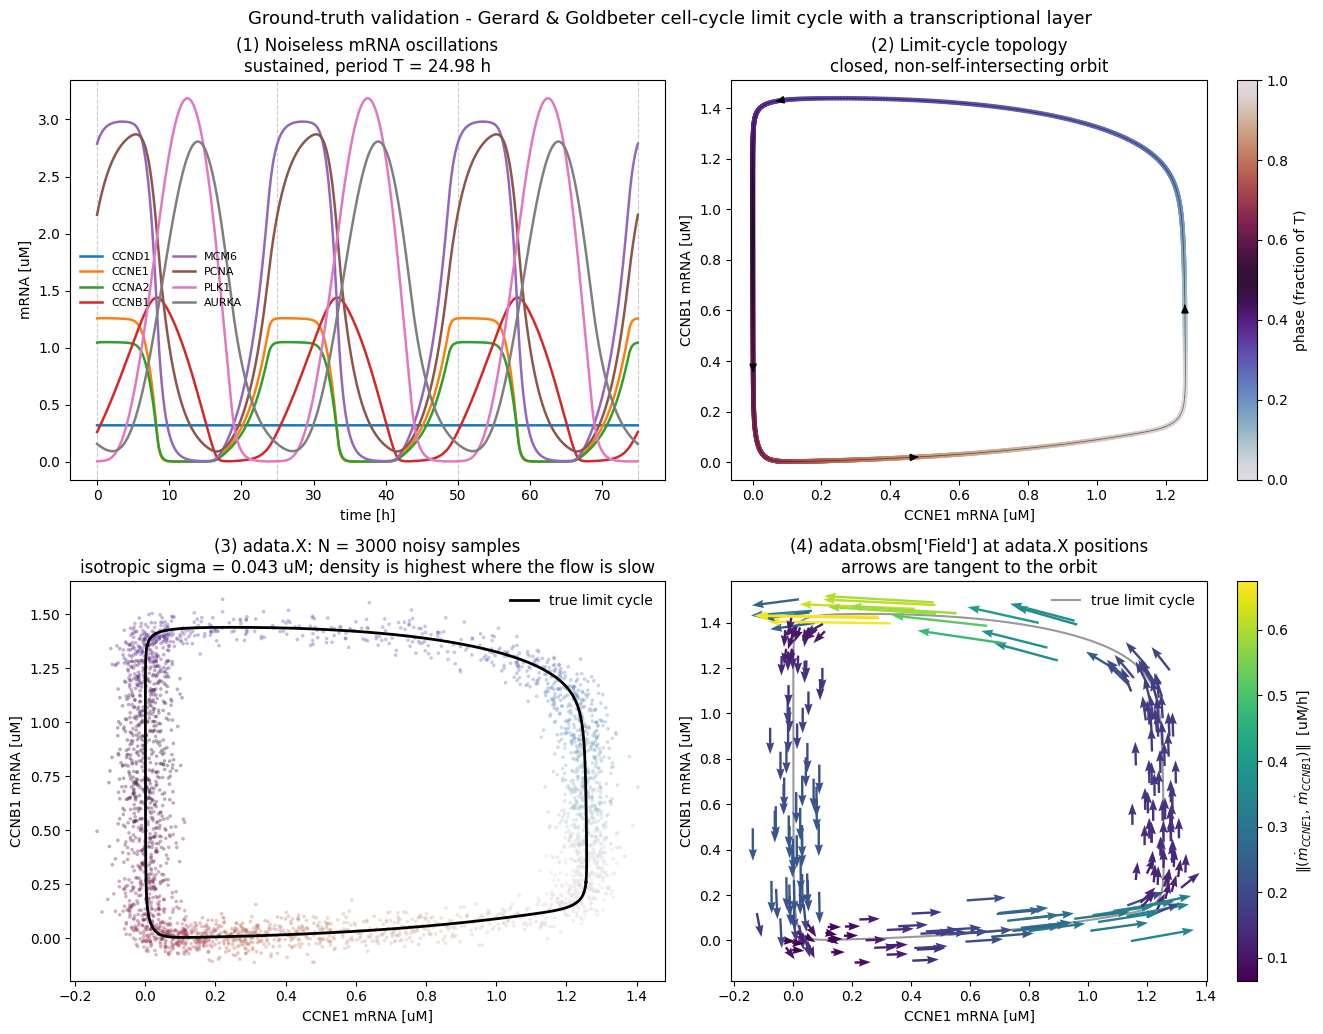

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 10.5))
GENES  = ccm.MRNA_GENES
i_e    = GENES.index("CCNE1")
i_b    = GENES.index("CCNB1")
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# ---------------------------------------------------------------- (1) time series
ax = axes[0, 0]
n_show = 3
ts = np.asarray(rr.simulate(0.0, n_show * PERIOD, 4001))
for k, g in enumerate(GENES):
    ax.plot(ts[:, 0], ts[:, 1 + MRNA_IDX[k]], lw=1.8, color=colors[k], label=g)
for j in range(n_show + 1):
    ax.axvline(j * PERIOD, color="0.8", lw=0.8, ls="--", zorder=0)
ax.set_xlabel("time [h]"); ax.set_ylabel("mRNA [uM]")
ax.set_title(f"(1) Noiseless mRNA oscillations\nsustained, period T = {PERIOD:.2f} h")
ax.legend(ncol=2, fontsize=8, frameon=False)

# ---------------------------------------------------------- (2) true phase portrait
ax = axes[0, 1]
cyc = np.asarray(rr.simulate(0.0, PERIOD, 2001))
xe, xb = cyc[:, 1 + MRNA_IDX[i_e]], cyc[:, 1 + MRNA_IDX[i_b]]
pts = ax.scatter(xe, xb, c=np.linspace(0, 1, len(xe)), cmap="twilight", s=6)
ax.plot(xe, xb, color="k", lw=0.6, alpha=0.5)
# direction of travel
for f in (0.10, 0.35, 0.60, 0.85):
    j = int(f * (len(xe) - 2))
    ax.annotate("", xy=(xe[j + 1], xb[j + 1]), xytext=(xe[j], xb[j]),
                arrowprops=dict(arrowstyle="-|>", color="k", lw=1.4))
plt.colorbar(pts, ax=ax, label="phase (fraction of T)")
ax.set_xlabel("CCNE1 mRNA [uM]"); ax.set_ylabel("CCNB1 mRNA [uM]")
ax.set_title("(2) Limit-cycle topology\nclosed, non-self-intersecting orbit")

# -------------------------------------------------------- (3) noisy data over cycle
ax = axes[1, 0]
ax.scatter(adata.X[:, i_e], adata.X[:, i_b], s=7, alpha=0.35,
           c=adata.obs["phase"], cmap="twilight", linewidths=0)
ax.plot(xe, xb, color="k", lw=2.0, label="true limit cycle")
ax.set_xlabel("CCNE1 mRNA [uM]"); ax.set_ylabel("CCNB1 mRNA [uM]")
ax.set_title(f"(3) adata.X: N = {N_CELLS} noisy samples\n"
             f"isotropic sigma = {sigma[0]:.3f} uM; density is highest where the flow is slow")
ax.legend(frameon=False, loc="upper right")

# ------------------------------------------------------------------ (4) quiver
ax = axes[1, 1]
sub = np.random.default_rng(SEED).choice(N_CELLS, size=220, replace=False)
u, v = adata.obsm["Field"][sub, i_e], adata.obsm["Field"][sub, i_b]
mag  = np.hypot(u, v)
ax.plot(xe, xb, color="0.6", lw=1.5, zorder=0, label="true limit cycle")
q = ax.quiver(adata.X[sub, i_e], adata.X[sub, i_b], u, v, mag,
              cmap="viridis", angles="xy", scale_units="xy",
              scale=1.6, width=0.005, headwidth=3.5)
plt.colorbar(q, ax=ax, label=r"$\|(\dot m_{CCNE1},\, \dot m_{CCNB1})\|$  [uM/h]")
ax.set_xlabel("CCNE1 mRNA [uM]"); ax.set_ylabel("CCNB1 mRNA [uM]")
ax.set_title("(4) adata.obsm['Field'] at adata.X positions\narrows are tangent to the orbit")
ax.legend(frameon=False, loc="upper right")

fig.suptitle("Ground-truth validation - Gerard & Goldbeter cell-cycle limit cycle "
             "with a transcriptional layer", fontsize=13)
fig.tight_layout()
plt.show()

In [15]:
# ---- quantitative version of panel (4): are the arrows really tangent? ----
# Compare the ground-truth field to the numerical tangent of the true orbit,
# in the FULL 8-gene transcript space.  cos(angle) should be ~1 everywhere.
dense = np.asarray(rr.simulate(0.0, PERIOD, 20_001))[:, 1:][:, MRNA_IDX]
tang  = np.gradient(dense, axis=0)
tang /= np.linalg.norm(tang, axis=1, keepdims=True)
f_here = ccm.exact_rates(rr, np.asarray(rr.simulate(0.0, PERIOD, 20_001))[:, 1:])[:, MRNA_IDX]
f_here /= np.linalg.norm(f_here, axis=1, keepdims=True) + 1e-12
cosang = np.einsum("ij,ij->i", tang, f_here)
print(f"cos(angle between Field and orbit tangent): "
      f"min {cosang.min():.6f}, median {np.median(cosang):.6f}")
print("-> the stored field is tangent to the orbit, as it must be.")

cos(angle between Field and orbit tangent): min 1.000000, median 1.000000
-> the stored field is tangent to the orbit, as it must be.


## 8. Supplementary: where is the Hopf bifurcation?

Not part of the required output, but it substantiates the claim that `GF = 1` is safely in the
oscillatory regime. We sweep `GF` and record the peak-to-trough amplitude of cyclin B/Cdk1 — a cheap
numerical stand-in for the paper's Figure 3a / Figure 8d.

Two honest caveats about what you will see:

* The transcriptional lag shifts the Hopf point slightly **below** `GF = 0`, so at `GF = 0` a
  micro-oscillation of amplitude ≈ 0.02 µM survives instead of a clean fixed point (the published
  5-variable model is quiescent there). That is 0.5% of the proliferative amplitude and it is the
  expected direction of the perturbation — more phase lag, larger oscillatory region.
* The functionally meaningful transition — the steep rise to full amplitude — is near
  `GF ≈ 0.1 µM`, matching the paper. This is also the region where it reports **birhythmicity**,
  which is precisely why we sample at `GF = 1`, an order of magnitude clear of it.

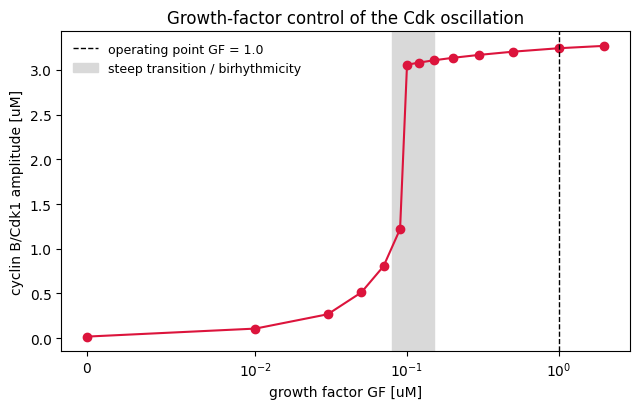

  GF = 0.0   amplitude = 0.0182 uM
  GF = 0.01  amplitude = 0.1076 uM
  GF = 0.03  amplitude = 0.2679 uM
  GF = 0.05  amplitude = 0.5124 uM
  GF = 0.07  amplitude = 0.8046 uM
  GF = 0.09  amplitude = 1.2200 uM
  GF = 0.1   amplitude = 3.0565 uM
  GF = 0.12  amplitude = 3.0808 uM
  GF = 0.15  amplitude = 3.1060 uM
  GF = 0.2   amplitude = 3.1337 uM
  GF = 0.3   amplitude = 3.1670 uM
  GF = 0.5   amplitude = 3.2026 uM
  GF = 1.0   amplitude = 3.2410 uM
  GF = 2.0   amplitude = 3.2676 uM


In [16]:
gf_vals = np.array([0.0, 0.01, 0.03, 0.05, 0.07, 0.09, 0.10, 0.12, 0.15, 0.2, 0.3, 0.5, 1.0, 2.0])
amps = ccm.gf_scan(ANTIMONY_MODEL, gf_vals)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(gf_vals, amps, "o-", color="crimson")
ax.axvline(GF, color="k", ls="--", lw=1, label=f"operating point GF = {GF}")
ax.axvspan(0.08, 0.15, color="0.85", zorder=0, label="steep transition / birhythmicity")
ax.set_xscale("symlog", linthresh=0.01)
ax.set_xlabel("growth factor GF [uM]")
ax.set_ylabel("cyclin B/Cdk1 amplitude [uM]")
ax.set_title("Growth-factor control of the Cdk oscillation")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

for g, a in zip(gf_vals, amps):
    print(f"  GF = {g:<5} amplitude = {a:.4f} uM")

## 9. Save

In [17]:
out = "cellcycle_limitcycle_scrna.h5ad"
adata.write_h5ad(out)
print("wrote", out)
print(adata)

wrote cellcycle_limitcycle_scrna.h5ad
AnnData object with n_obs × n_vars = 3000 × 8
    obs: 'true_time', 'phase', 'cell_cycle_phase', 'speed'
    var: 'driver', 'amplitude', 'oscillating'
    uns: 'model'
    obsm: 'Field', 'X_protein', 'Field_protein'
    layers: None (.X), 'noiseless'


## 10. What to turn, and what to watch out for

**Knobs, in rough order of usefulness for stress-testing a recovery method**

| knob | effect |
|---|---|
| `NOISE_FRAC` | tube thickness. Above ~0.15 the mitotic spike is buried and the loop starts to look like a blob. Sweep it to find where the method breaks. |
| `N_CELLS` | sampling density. The interesting failure is at low N in the *fast* (sparsely sampled) part of the orbit. |
| `NOISE`, `isotropic=False` | anisotropic noise — tests whether the method is secretly relying on isotropy. |
| `GF` | 0.05–0.09 gives a genuinely small-amplitude cycle; a harder, lower-SNR target. |
| `b_*` in the model | slower mRNA ⇒ larger phase lag ⇒ rounder, more circular orbit; faster mRNA ⇒ a more spiked, harder shape. |
| `Kdb` | raise it (say 0.05) to soften the near-zero-order mitotic degradation and make the cycle less stiff. |
| reporter genes | delete them for an 8→4-dimensional problem, or duplicate them with fresh `beta` values to push the ambient dimension up. |

**Things that will bite if you forget them**

1. **`Field` is a projection, not a closed field.** It is single-valued *on the attractor* only,
   and only because we checked the embedding margin. Any method that queries the field at points
   far off the cycle is asking a question this dataset cannot answer.
2. **Density and speed are anti-correlated by construction.** This is correct physics, not a
   sampling bug, and it is the main thing that makes the problem non-trivial.
3. **`CCND1` is constant.** It is a deliberate negative control: an expressed, non-cycling gene
   with zero true velocity. A method that assigns it a systematic non-zero field is hallucinating.
4. **`true_time` is not identifiable from `X`.** A stationary population has no absolute clock.
   Score against `obs['phase']` (a circular coordinate, so use a circular metric) — not against
   `true_time`, whose 8 wrapped periods are indistinguishable from one another.
5. **The noise is not clipped**, so `X` contains small negative values for low-expressed genes.
   That is intentional (it keeps the tube Gaussian); set `clip_negative=True` if a downstream
   step requires non-negativity.
6. **Not counts.** Add a negative-binomial layer on top of `layers['noiseless']` when you are ready
   to test the normalisation pipeline as well as the geometry — but do that as a second experiment,
   not as a confound in the first.